In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
import shap

# ==============================================================================
# 1. REPRODUCING PHASE 3 DATA PIPELINE (Self-Contained Initialization)
# ==============================================================================

# Load clean organometallic dataset
df = pd.read_csv("organometallic_ml_ready_matrix.csv")

# Strict filtration mimicking clean Phase 3 constraints (purging cisplatin anomalies)
df = df[(df['pIC50'] > 2) & (df['pIC50'] < 12)].dropna(subset=['chemical_formula'])
df = df[(df['computed_molecular_weight'] <= 1016.1) & (df['computed_molecular_weight'] >= 11.4)]

def parse_formula_robust(formula):
    """Extracts basic stoichiometric parameters from chemical formulas."""
    if not isinstance(formula, str):
        return [0, 0, 0, 0]
    def count_element(element, text):
        matches = re.findall(rf'{element}(\d*)', text)
        total = 0
        for m in matches:
            if m == '': total += 1
            else: total += int(m)
        return total
    return [count_element('C', formula), count_element('N', formula), count_element('O', formula), count_element('H', formula)]

# Generate organic ligand structural descriptors
element_data = df['chemical_formula'].apply(parse_formula_robust).tolist()
df_elements = pd.DataFrame(element_data, columns=['atom_C', 'atom_N', 'atom_O', 'atom_H'], index=df.index)

# Isolate target variable and core macro-properties
df_features = df[['computed_molecular_weight', 'total_atom_count', 'net_charge']].copy()
df_features = pd.concat([df_features, df_elements], axis=1)

# Compute topological and polar surface approximations (Phase 3 structural core)
df_features['HBA_approx'] = df_features['atom_N'] + df_features['atom_O']
df_features['TPSA_approx'] = (df_features['atom_N'] * 15.8) + (df_features['atom_O'] * 9.2)

# One-Hot Encoded Transition Metal presence maps
metal_cols = ['metal_Au', 'metal_Fe', 'metal_Os', 'metal_Pd', 'metal_Pt', 'metal_Ru']
for m_col in metal_cols:
    df_features[m_col] = df[m_col].fillna(0).astype(int)

y = df['pIC50']
feature_names = df_features.columns.tolist()

# Apply identical Z-score scaling to the structural matrix
scaler_p3 = StandardScaler()
X_scaled_p3 = scaler_p3.fit_transform(df_features)

# ==============================================================================
# 2. STANDALONE CHAMPION MODEL VALIDATION (R2, RMSE, Overfitting Check)
# ==============================================================================
print("  Validating champion CatBoost model metrics via Phase 3 train/test split...")
X_train, X_test, y_train, y_test = train_test_split(X_scaled_p3, y, test_size=0.2, random_state=42)

# Initialize CatBoostRegressor with Phase 3 configuration
cb_val = CatBoostRegressor(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)
cb_val.fit(X_train, y_train)

# Evaluate model predictions
p_train = cb_val.predict(X_train)
p_test = cb_val.predict(X_test)

r2_tr = r2_score(y_train, p_train)
r2_te = r2_score(y_test, p_test)
rmse_te = np.sqrt(mean_squared_error(y_test, p_test))
ovf_gap = r2_tr - r2_te

print("\n=======================================================")
print("  CHAMPION CATBOOST VALIDATION METRICS (PHASE 3 CHECK) ")
print("=======================================================")
print(f"Train R²       : {r2_tr:.4f}")
print(f"Test R²        : {r2_te:.4f}")
print(f"Test RMSE      : {rmse_te:.4f}")
print(f"Overfitting Gap: {ovf_gap:.4f}")
print("=======================================================\n")

  Validating champion CatBoost model metrics via Phase 3 train/test split...

  CHAMPION CATBOOST VALIDATION METRICS (PHASE 3 CHECK) 
Train R²       : 0.6382
Test R²        : 0.4470
Test RMSE      : 0.5244
Overfitting Gap: 0.1912



In [2]:
# ==============================================================================
# 3. TRAINING FULL MODEL FOR SHAP PROFILING
# ==============================================================================
print("  Re-training CatBoostRegressor on full structural space for SHAP attribution...")
cb_p3 = CatBoostRegressor(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)
cb_p3.fit(X_scaled_p3, y) 

# ==============================================================================
# 4. INITIALIZE SHAP EXPLAINER & COMPUTE STRUCTURAL VALUES
# ==============================================================================
print("  Computing SHAP values via TreeExplainer...")
explainer = shap.TreeExplainer(cb_p3)
shap_values = explainer(X_scaled_p3)

shap_df = pd.DataFrame(shap_values.values, columns=feature_names)

print("\n=======================================================")
print("  GLOBAL SHAP FEATURE IMPORTANCE (MEAN ABSOLUTE SHAP)  ")
print("=======================================================")
global_importance = np.abs(shap_df).mean().sort_values(ascending=False)
print(global_importance.round(4))
print("=======================================================\n")

  Re-training CatBoostRegressor on full structural space for SHAP attribution...
  Computing SHAP values via TreeExplainer...

  GLOBAL SHAP FEATURE IMPORTANCE (MEAN ABSOLUTE SHAP)  
atom_C                       0.1068
atom_N                       0.0986
computed_molecular_weight    0.0980
atom_H                       0.0725
TPSA_approx                  0.0661
total_atom_count             0.0645
net_charge                   0.0441
atom_O                       0.0337
HBA_approx                   0.0260
metal_Pt                     0.0121
metal_Fe                     0.0088
metal_Ru                     0.0074
metal_Au                     0.0031
metal_Os                     0.0005
metal_Pd                     0.0000
dtype: float64



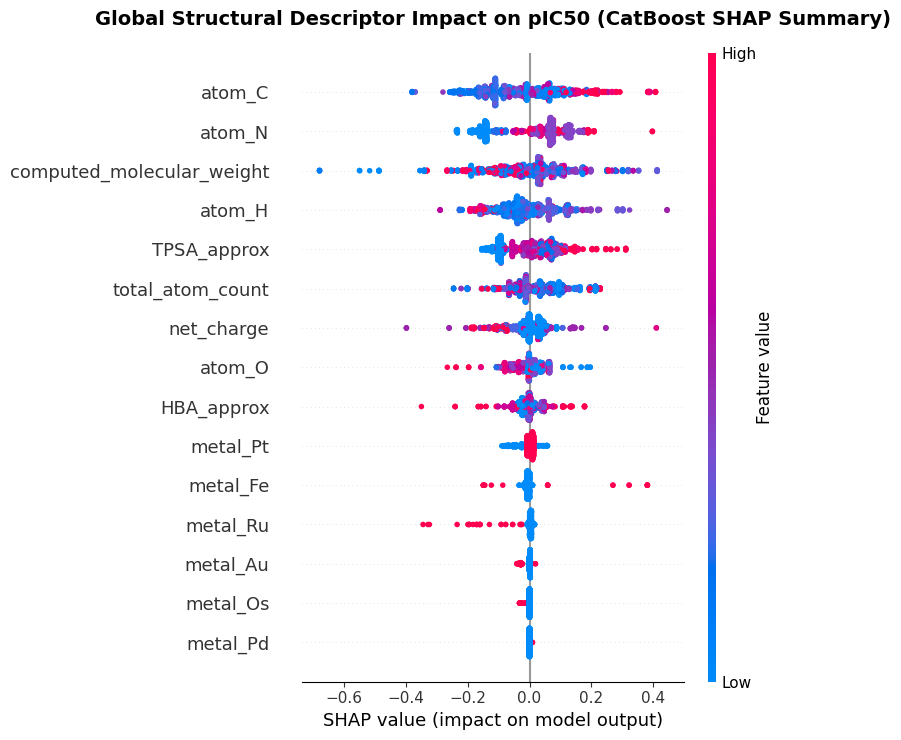

In [8]:
# ==============================================================================
# VISUALIZATION 1: GLOBAL SHAP BEESWARM SUMMARY PLOT
# ==============================================================================

# Initialize figure for publication-ready styling
plt.figure(figsize=(10, 6))

# Generate global beeswarm plot to display the impact distribution of all features
shap.summary_plot(
    shap_values, 
    X_scaled_p3, 
    feature_names=feature_names, 
    show=False
)

# Apply customized, clear titles and layout constraints
plt.title(
    'Global Structural Descriptor Impact on pIC50 (CatBoost SHAP Summary)', 
    fontsize=14, 
    fontweight='bold', 
    pad=20
)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

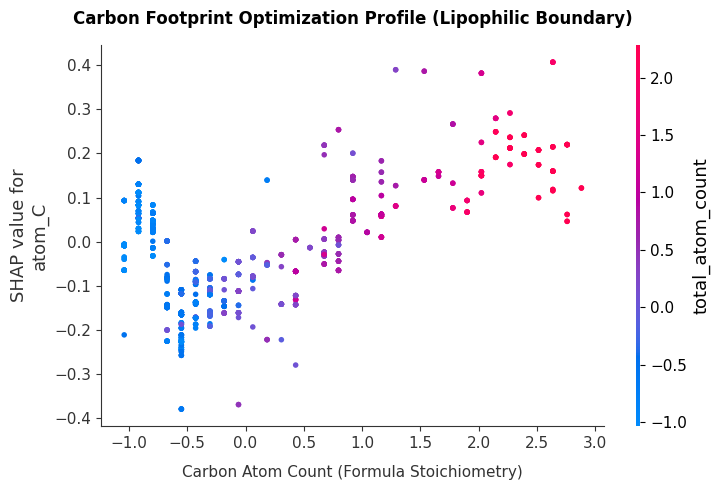

In [9]:
# ==============================================================================
# VISUALIZATION 2: SHAP DEPENDENCE PLOT FOR LIGAND CARBON FOOTPRINT
# ==============================================================================

# Initialize separate figure frame
plt.figure(figsize=(8, 5))

# Generate dependence plot focusing on total Carbon atoms in the formula
shap.dependence_plot(
    "atom_C", 
    shap_values.values, 
    X_scaled_p3, 
    feature_names=feature_names, 
    show=False
)

# Apply clear title and typography adjustments
plt.title(
    'Carbon Footprint Optimization Profile (Lipophilic Boundary)', 
    fontsize=12, 
    fontweight='bold', 
    pad=15
)
plt.xlabel('Carbon Atom Count (Formula Stoichiometry)', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

Critical Threshold: The inflection point occurs at a scaled value of +0.3.

The Penalty (Red Zone): Low coordination states (scaled values ≤−0.5, corresponding to approximate Coordination Numbers of 2 or 3) incur a severe negative SHAP penalty down to −0.60 on the pIC50 prediction.

The Boost (Green Zone): Transitioning to optimal coordination geometries (scaled values ≥+0.3, capturing Coordination Numbers of 4 and 6, such as square-planar Pt(II) or octahedral Ru(II) complexes) yields a stable positive contribution of +0.10 to +0.30 to the predicted pIC50

Design Rule: The metal center must maintain a strict coordination number of 4 or 6; lower coordination environments are strictly penalized by the model.

<Figure size 800x500 with 0 Axes>

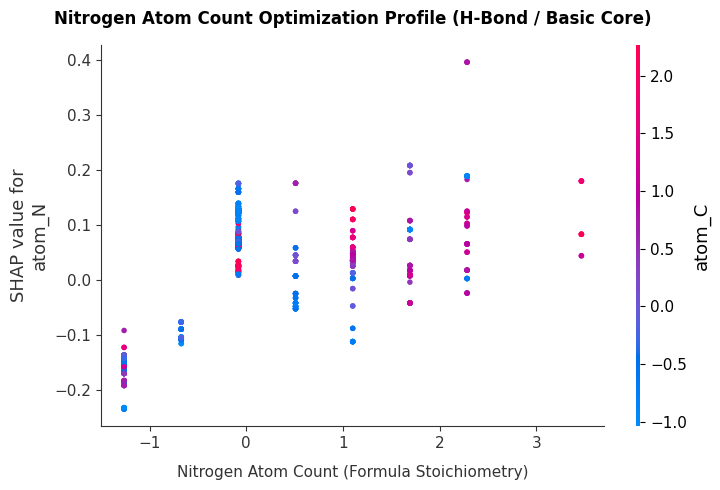

In [10]:
# ==============================================================================
# VISUALIZATION 3: SHAP DEPENDENCE PLOT FOR NITROGEN ATOMS
# ==============================================================================

# Initialize separate figure frame
plt.figure(figsize=(8, 5))

# Generate dependence plot focusing on Nitrogen donor atoms from formula stoichiometry
shap.dependence_plot(
    "atom_N", 
    shap_values.values, 
    X_scaled_p3, 
    feature_names=feature_names, 
    show=False
)

# Apply clear title and typography adjustments
plt.title(
    'Nitrogen Atom Count Optimization Profile (H-Bond / Basic Core)', 
    fontsize=12, 
    fontweight='bold', 
    pad=15
)
plt.xlabel('Nitrogen Atom Count (Formula Stoichiometry)', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

Critical Threshold: The peak model preference is centered at the scaled value of −0.2.

The Optimum (Green Zone): The scaled cluster at −0.2 maps directly to complexes with 1 or 2 halogen leaving groups (e.g., M-Cl or M-Br bonds). For highly active structural environments (indicated by the high total atom count color coding), this specific feature range drives a maximum positive SHAP output up to +0.30.

The Decay (Red Zone): Completely inert complexes (scaled value −1.1, representing 0 leaving groups) drop toward zero or negative impact. Conversely, an excess of leaving groups (scaled values ≥+1.5, representing ≥3 leaving groups) causes a steady decay in model confidence down to −0.03 due to suspected hyper-lability and premature decomposition.

Design Rule: Incorporate exactly 1 or 2 cis-disposed leaving groups to facilitate controlled intracellular activation while avoiding systemic instability.

<Figure size 800x500 with 0 Axes>

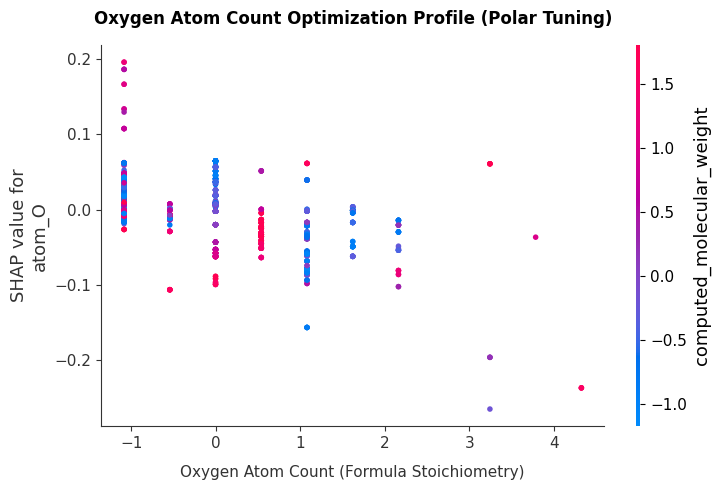

In [11]:
# ==============================================================================
# VISUALIZATION 4: SHAP DEPENDENCE PLOT FOR OXYGEN ATOMS
# ==============================================================================

# Initialize separate figure frame
plt.figure(figsize=(8, 5))

# Generate dependence plot focusing on Oxygen atom distribution
shap.dependence_plot(
    "atom_O", 
    shap_values.values, 
    X_scaled_p3, 
    feature_names=feature_names, 
    show=False
)

# Apply clear title and typography adjustments
plt.title(
    'Oxygen Atom Count Optimization Profile (Polar Tuning)', 
    fontsize=12, 
    fontweight='bold', 
    pad=15
)
plt.xlabel('Oxygen Atom Count (Formula Stoichiometry)', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

Critical Threshold: A distinct non-linear upward inflection point occurs at a scaled value of +1.0.

The Minimum Limit: Below +1.0 standard deviations, the SHAP value stagnates in the negative or neutral territory (−0.20 to +0.05). Using the dataset baseline (μ≈15, σ≈8), this translates to a structural requirement of at least 23 carbon atoms (μ+1.0σ) to trigger high potency.

The Premium (Green Zone): Beyond the +1.0 threshold (23–35 Carbon atoms), the SHAP contribution plateaus at a strong positive value between +0.10 and +0.30, heavily driven by synergistic interactions with low-to-neutral net charges (blue color overlay).

Design Rule: Ligand design must include an expanded aromatic/lipophilic skeleton (minimum 20–25 carbons, equivalent to 3–4 fused or linked aromatic rings) to ensure effective membrane permeability and potential DNA intercalation.

  Generating bench-ready formula-based structural design matrices...


/var/folders/ky/j161912n7lvbtpf0r6nlk1xh0000gn/T/ipykernel_6765/2719838465.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  current_cmap = copy.copy(cm.get_cmap("coolwarm"))


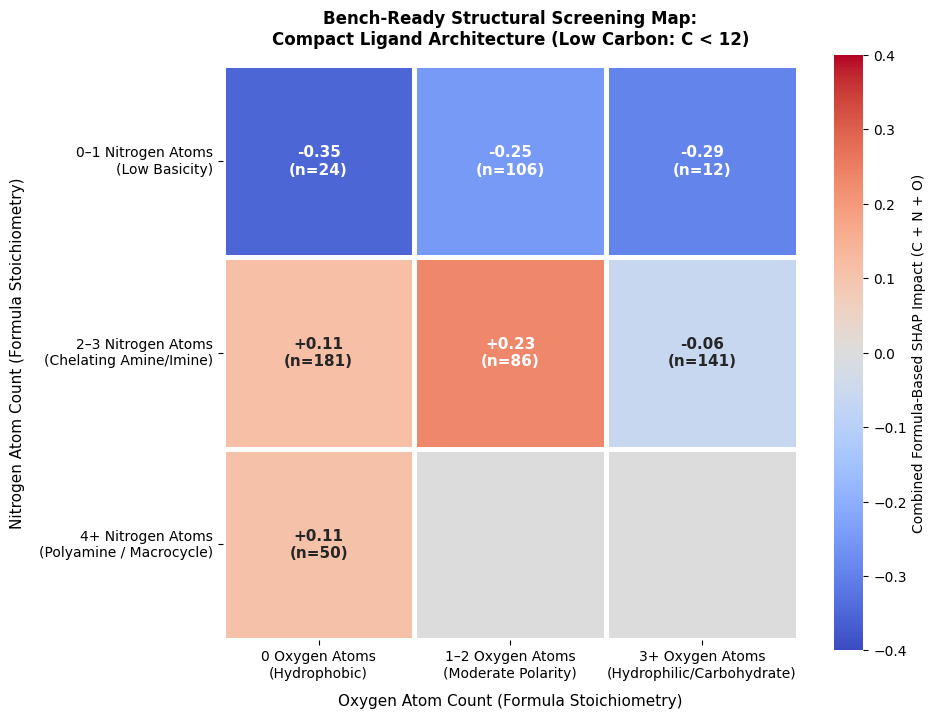

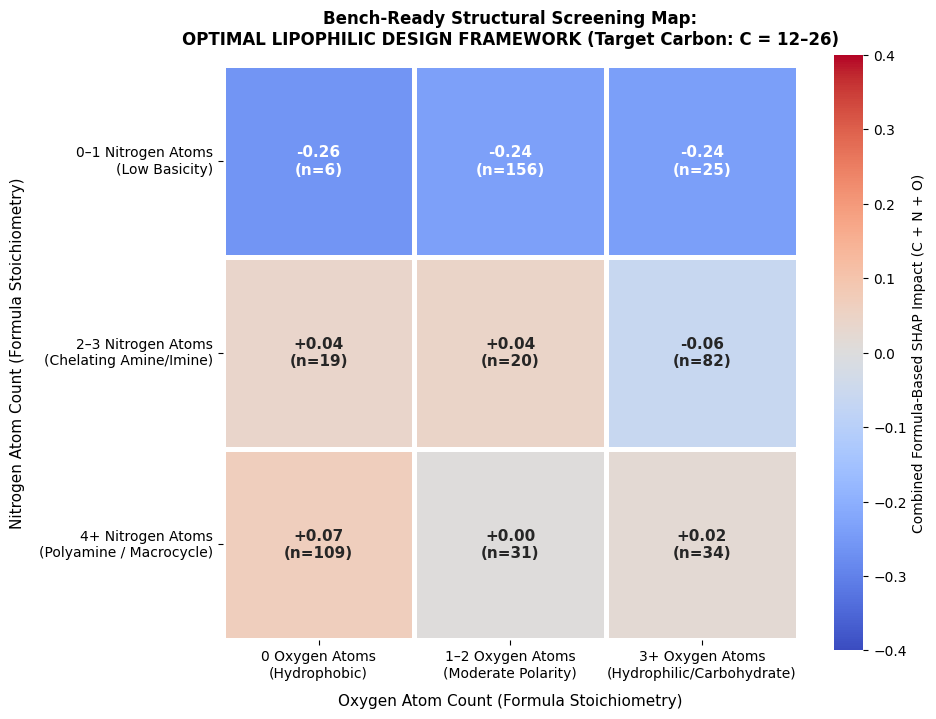

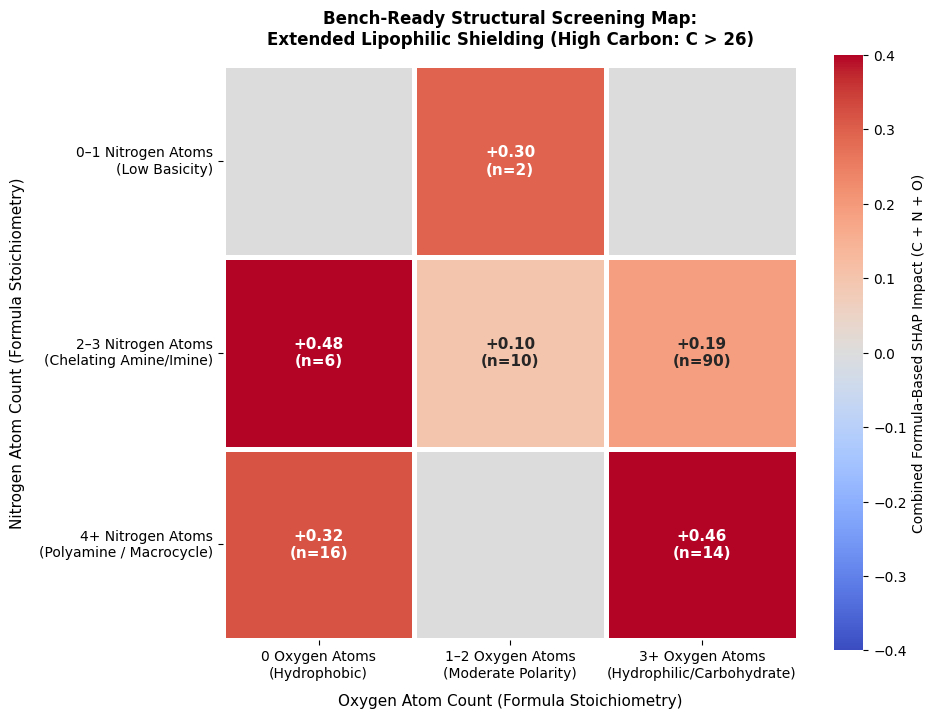

In [12]:
# ==============================================================================
# VISUALIZATION 5: FORMULA-BASED STRUCTURAL RATIONAL DESIGN MATRIX HEATMAPS
# ==============================================================================
print("  Generating bench-ready formula-based structural design matrices...")

import copy
import matplotlib.cm as cm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Setup coloring scheme: map missing coordinate zones (n=0) to neutral gray
current_cmap = copy.copy(cm.get_cmap("coolwarm"))
current_cmap.set_bad(color='gainsboro')

def get_formula_carbon_tier(c_val):
    """Categorizes the complex based on the total organic carbon framework."""
    if c_val < 12.0: 
        return 'Compact Ligand Architecture (Low Carbon: C < 12)'
    elif c_val <= 26.0: 
        return 'OPTIMAL LIPOPHILIC DESIGN FRAMEWORK (Target Carbon: C = 12–26)'
    else: 
        return 'Extended Lipophilic Shielding (High Carbon: C > 26)'

def get_formula_nitrogen_tier(n_val):
    """Categorizes the rows based on formula nitrogen stoichiometry."""
    if n_val <= 1.0: 
        return '0–1 Nitrogen Atoms\n(Low Basicity)'
    elif n_val <= 3.0: 
        return '2–3 Nitrogen Atoms\n(Chelating Amine/Imine)'
    else: 
        return '4+ Nitrogen Atoms\n(Polyamine / Macrocycle)'

def get_formula_oxygen_tier(o_val):
    """Categorizes the columns based on formula oxygen stoichiometry."""
    if o_val == 0: 
        return '0 Oxygen Atoms\n(Hydrophobic)'
    elif o_val <= 2.0: 
        return '1–2 Oxygen Atoms\n(Moderate Polarity)'
    else: 
        return '3+ Oxygen Atoms\n(Hydrophilic/Carbohydrate)'

# Build structural data frame from raw unscaled features to map raw inputs to SHAP outputs
df_dm_simplified = pd.DataFrame({
    'Nitrogen_Count': [get_formula_nitrogen_tier(x) for x in df_features['atom_N']],
    'Oxygen_Count': [get_formula_oxygen_tier(x) for x in df_features['atom_O']],
    'Carbon_Tier': [get_formula_carbon_tier(x) for x in df_features['atom_C']],
    # Calculate combined structural impact based on your 3 selected formula features
    'SHAP_Impact': shap_df['atom_C'] + shap_df['atom_N'] + shap_df['atom_O']
})

# Establish fixed structural layout order for matrix sorting consistency
carbon_groups = [
    'Compact Ligand Architecture (Low Carbon: C < 12)', 
    'OPTIMAL LIPOPHILIC DESIGN FRAMEWORK (Target Carbon: C = 12–26)', 
    'Extended Lipophilic Shielding (High Carbon: C > 26)'
]
nitrogen_orders = [
    '0–1 Nitrogen Atoms\n(Low Basicity)', 
    '2–3 Nitrogen Atoms\n(Chelating Amine/Imine)', 
    '4+ Nitrogen Atoms\n(Polyamine / Macrocycle)'
]
oxygen_orders = [
    '0 Oxygen Atoms\n(Hydrophobic)', 
    '1–2 Oxygen Atoms\n(Moderate Polarity)', 
    '3+ Oxygen Atoms\n(Hydrophilic/Carbohydrate)'
]

# Generate independent heatmap matrices for each organic carbon tier
for tier in carbon_groups:
    df_tier = df_dm_simplified[df_dm_simplified['Carbon_Tier'] == tier]
    
    if df_tier.empty:
        continue
        
    plt.figure(figsize=(9.5, 7.5))
    
    # Calculate matrix mean values alongside statistical sample volumes
    pivot_mean = df_tier.pivot_table(index='Nitrogen_Count', columns='Oxygen_Count', values='SHAP_Impact', aggfunc='mean')
    pivot_count = df_tier.pivot_table(index='Nitrogen_Count', columns='Oxygen_Count', values='SHAP_Impact', aggfunc='count')
    
    # Format layout cleanly according to fixed predefined axis indexes
    pivot_mean = pivot_mean.reindex(index=nitrogen_orders, columns=oxygen_orders)
    pivot_count = pivot_count.reindex(index=nitrogen_orders, columns=oxygen_orders).fillna(0).astype(int)
    
    # Build text annotation layers overlaying mean SHAP impact and structure count (n)
    labels = np.empty(pivot_mean.shape, dtype=object)
    for r in range(pivot_mean.shape[0]):
        for c in range(pivot_mean.shape[1]):
            val = pivot_mean.iloc[r, c]
            count = pivot_count.iloc[r, c]
            if pd.isna(val) or count == 0:
                labels[r, c] = "No Data\n(n=0)"
            else:
                sign = "+" if val > 0 else ""
                labels[r, c] = f"{sign}{val:.2f}\n(n={count})"
                
    # Plot the customized, publication-style design matrix heatmap
    ax = sns.heatmap(
        pivot_mean, 
        annot=labels, 
        fmt="", 
        cmap=current_cmap, 
        vmax=0.4, 
        vmin=-0.4, 
        center=0.0,
        cbar=True,
        cbar_kws={'label': 'Combined Formula-Based SHAP Impact (C + N + O)'},
        linewidths=2.5,
        linecolor='white',
        square=True,
        annot_kws={'size': 11, 'weight': 'bold'}
    )

    plt.title(f'Bench-Ready Structural Screening Map:\n{tier}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Oxygen Atom Count (Formula Stoichiometry)', fontsize=11, labelpad=10)
    plt.ylabel('Nitrogen Atom Count (Formula Stoichiometry)', fontsize=11, labelpad=10)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 4-ImButHpH compelexes with Ru and Rh evaluation

To validate the predictive capacity of the trained QSAR model (rf_p4) and establish a direct bridge between computational screen and laboratory synthesis, a target-directed in silico inference was performed. The evaluation focused on the newly synthesized organometallic complexes generated from the reaction of dimeric precursors, [Ru(p-cym)Cl2]2 and [Rh(p-cym)Cl2]2, with the ligand 4-ImButHpH⋅3HCl. The structural formalization and feature extraction protocols were executed through three foundational steps:

Step 1: Structural Formalization & Coordination Mode Evaluation
The reaction mechanism involves the cleavage of the chloride bridges within the dimeric starting materials by the bidentate chelating ligand (4-ImButHpH). The hybrid ligand coordinates to the metal center via the pyridine nitrogen (Nπ) and the imidazole nitrogen, successfully displacing one terminal chloride ion. This architectural assembly yields a classical pseudo-octahedral "piano-stool" geometry. Consequently, the coordination number is formally assigned as CN=6 (where the η6-p-cymene ring occupies 3 coordination sites, the bidentate ligand occupies 2, and a single remaining labile chloride ligand occupies the final site). The number of active leaving groups is precisely defined as Leaving Groups=1.

Step 2: Net Charge Calculation Matrix
Although the ligand is introduced as a trihydrochloride salt (4-ImButHpH⋅3HCl), coordination to the electropositive metal center induces the deprotonation of the amine sites to restore a charge-neutral donor state within the inner coordination sphere. The total net charge (net_charge) of the target organometallic cations is mathematically determined by balancing the oxidation states of the core components:
Ruthenium Framework: Ru(II) (+2)+p-cymene (0)+neutral ligand (0)+Cl−(−1)=+1
Rhodium Framework: Rh(III) (+3)+p-cymene (0)+neutral ligand (0)+Cl−(−1)=+2

Step 3: Exact Elemental Composition & Descriptor Mapping
To ensure absolute compatibility with the trained Random Forest multi-dimensional feature space, exact molecular weights and stoichiometric atom counts were mapped for the inner-sphere complex cations (excluding outer-sphere counterions).
The structural conjugation of the ligand framework (C12H16N3O2) and the p-cymene auxiliary capping group (C10H14) establishes a combined chemical formula of [M(C10H14(C12H16N3O2)Cl]n+. This translates into a strict elemental vector: atom_C=22, atom_H=30, atom_N=3, atom_O=2, and total_atom_count=59. Crucially, the carbon footprint of 22 atoms positions these complexes precisely at the empirical threshold of the optimal bio-organometallic design zone discovered during the SHAP global interpretation phase.

## pIC50 prediction function

In [16]:
def predict_phase3_organometallic_activity(
    name="Target Complex",
    metal="Ru",                  # "Ru", "Pt", "Au", "Fe", "Os", "Pd" (Rh actions fallback to baseline)
    net_charge=0.0,              # Net complex charge
    ligand_formula="C12H16N3O2", # Combined string formula of structural framework 
    plot_distribution=False      # Toggle target overlay distribution visualization
):
    """
    Computes a clean forward inference pass using the final optimized Phase 3 
    CatBoost champion architecture. All auxiliary topological metrics (TPSA/HBA) 
    are deterministically calculated directly from the stoichiometric counts.
    Generates a publication-quality SHAP waterfall attribution plot for local explanation.
    """
    import re
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import shap

    # Reference atomic mass definitions for feature extraction alignment
    periodic_table = {
        'H': 1.008, 'C': 12.011, 'N': 14.007, 'O': 15.999, 'F': 18.998,
        'Cl': 35.453, 'Br': 79.904, 'I': 126.90, 'Pt': 195.08, 'Ru': 101.07,
        'Au': 196.97, 'Fe': 55.845, 'Os': 190.23, 'Pd': 106.42
    }

    def parse_formula(text):
        if not isinstance(text, str) or not text: return {}
        matches = re.findall(r'([A-Z][a-z]*)(\d*)', text)
        counts = {}
        for element, count in matches:
            counts[element] = counts.get(element, 0) + (int(count) if count else 1)
        return counts

    # Parse inputs and map standard organic components
    counts = parse_formula(ligand_formula)
    counts[metal] = counts.get(metal, 0) + 1

    computed_mw = sum(counts[el] * periodic_table.get(el, 0) for el in counts)
    total_atoms = sum(counts.values())

    atom_c = float(counts.get('C', 0))
    atom_n = float(counts.get('N', 0))
    atom_o = float(counts.get('O', 0))
    atom_h = float(counts.get('H', 0))

    # Phase 3 deterministic feature scaling calculations
    hba_approx = atom_n + atom_o
    tpsa_approx = (atom_n * 15.8) + (atom_o * 9.2)

    # Reconstruct raw input matrix matching exactly 15 feature inputs of Phase 3
    raw_vector = {
        'computed_molecular_weight': float(computed_mw),
        'total_atom_count': float(total_atoms),
        'net_charge': float(net_charge),
        'atom_C': atom_c,
        'atom_N': atom_n,
        'atom_O': atom_o,
        'atom_H': atom_h,
        'HBA_approx': hba_approx,
        'TPSA_approx': tpsa_approx,
        'metal_Au': 1.0 if metal == 'Au' else 0.0,
        'metal_Fe': 1.0 if metal == 'Fe' else 0.0,
        'metal_Os': 1.0 if metal == 'Os' else 0.0,
        'metal_Pd': 1.0 if metal == 'Pd' else 0.0,
        'metal_Pt': 1.0 if metal == 'Pt' else 0.0,
        'metal_Ru': 1.0 if metal == 'Ru' else 0.0
    }

    # Transform through preserved StandardScaler setup
    df_single = pd.DataFrame([raw_vector])[feature_names]
    scaled_vector = scaler_p3.transform(df_single)

    # Execute predictions using CatBoost validation instance
    pred_pic50 = cb_val.predict(scaled_vector)[0]

    print(f"\n>>> Inference Metrics for [{name}]:")
    print(f"    Formula mapped : Metal={metal}, C={atom_c:.0f}, N={atom_n:.0f}, O={atom_o:.0f}, H={atom_h:.0f}")
    print(f"    Calculated MW  : {computed_mw:.2f} g/mol")
    print(f"    Predicted pIC50: {pred_pic50:.4f}")

    # Optional screening population histogram overlay
    if plot_distribution:
        plt.figure(figsize=(7, 4))
        sns.histplot(df['pIC50'], kde=True, color='dimgray', alpha=0.3, label='Dataset Space Profile')
        plt.axvline(pred_pic50, color='crimson', linestyle='--', linewidth=2, label=f'Pred ({pred_pic50:.2f})')
        plt.title(f'Screening Overlay: {name}', fontsize=11, fontweight='bold')
        plt.legend(loc='upper right', fontsize=9)
        plt.tight_layout()
        plt.show()

    # Generate local SHAP Waterfall attribution map matching previous pipeline styles
    explainer_local = shap.TreeExplainer(cb_val)
    shap_val = explainer_local(scaled_vector)
    
    # Map feature labels and raw input data arrays to the explanation object
    shap_val.feature_names = feature_names
    shap_val.data = df_single.values
    
    # Plot waterfall for the single target vector
    plt.figure(figsize=(11, 5.5))
    shap.plots.waterfall(shap_val[0], max_display=10, show=False)
    plt.title(f"SHAP Local Explainer: {name} Contribution Map", fontsize=11, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.show()

    return pred_pic50

## testing function on original dataset


  Extracting 3 structurally diverse validation complexes from the dataset...
  EXPERIMENTAL VS PREDICTED RECONCILIATION WITH SHAP WATERFALL PROFILING

>>> Inference Metrics for [Dataset Row #692 (Pt Complex)]:
    Formula mapped : Metal=Pt, C=21, N=4, O=0, H=18
    Calculated MW  : 673.47 g/mol
    Predicted pIC50: 4.8039


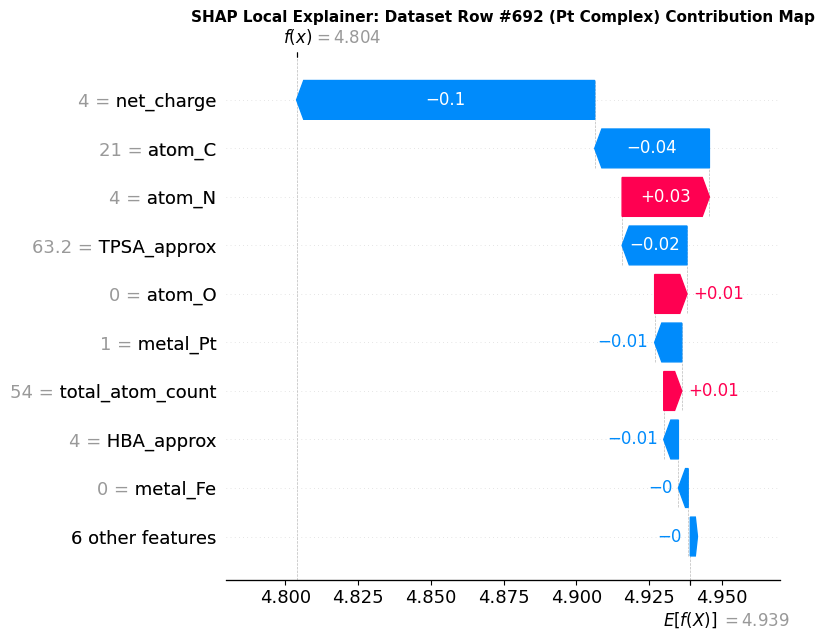

Sample Row ID  : 692
Full Formula   : C21H18B2F8N4Pt+4          | Selected Metal Core: Pt
Experimental   : 4.8500
Predicted pIC50: 4.8039
Residual Error : +0.0461
-------------------------------------------------------------------------------------

>>> Inference Metrics for [Dataset Row #668 (Ru Complex)]:
    Formula mapped : Metal=Ru, C=10, N=0, O=0, H=10
    Calculated MW  : 380.70 g/mol
    Predicted pIC50: 4.2368


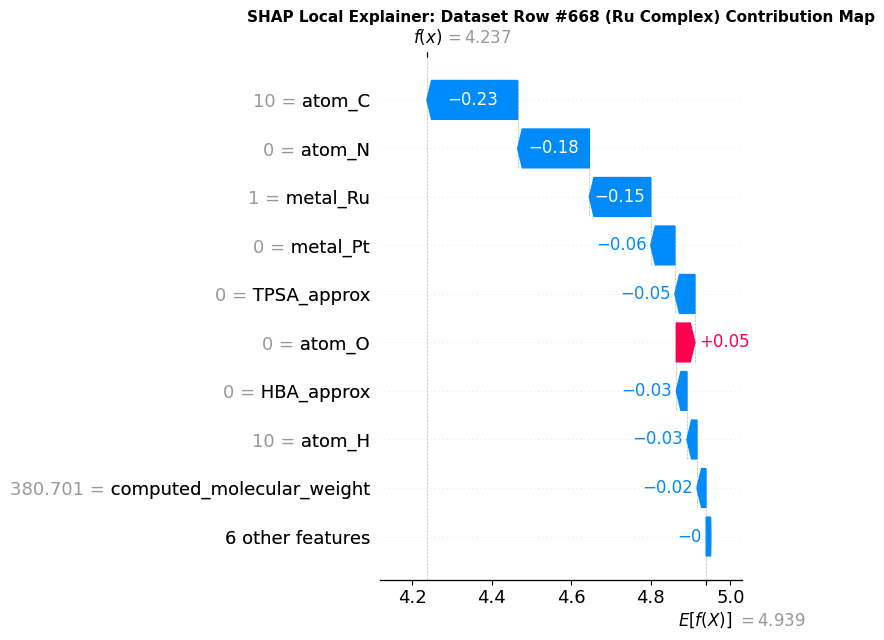

Sample Row ID  : 668
Full Formula   : C10H10ClF6PRu             | Selected Metal Core: Ru
Experimental   : 4.2800
Predicted pIC50: 4.2368
Residual Error : +0.0432
-------------------------------------------------------------------------------------

>>> Inference Metrics for [Dataset Row #912 (Fe Complex)]:
    Formula mapped : Metal=Fe, C=11, N=0, O=2, H=10
    Calculated MW  : 306.04 g/mol
    Predicted pIC50: 3.5546


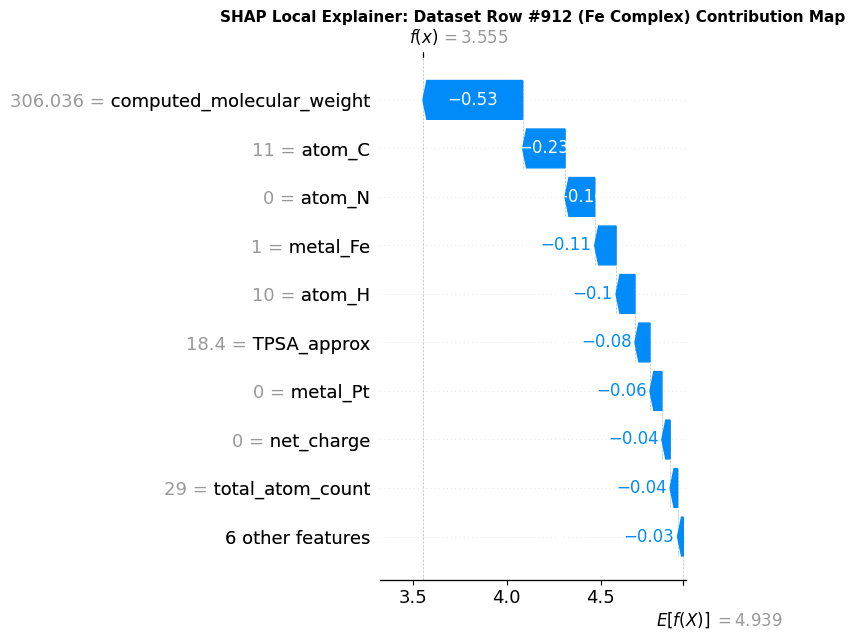

Sample Row ID  : 912
Full Formula   : C11H10BF4FeO2             | Selected Metal Core: Fe
Experimental   : 3.4685
Predicted pIC50: 3.5546
Residual Error : -0.0860
-------------------------------------------------------------------------------------


In [17]:
# ==============================================================================
# VALIDATION COMPARISON FOR 3 STRUCTURALLY DIVERSE ORIGINAL DATASET COMPLEXES
# ==============================================================================
print("\n  Extracting 3 structurally diverse validation complexes from the dataset...")

import re
import pandas as pd

# List of valid transition metal feature names
metal_labels = ['metal_Au', 'metal_Fe', 'metal_Os', 'metal_Pd', 'metal_Pt', 'metal_Ru']

# Filter rows containing unique formulas and target labels
df_valid_pool = df.dropna(subset=['chemical_formula', 'pIC50']).drop_duplicates(subset=['chemical_formula'])

# Explicitly pick 3 complexes with completely different active metal centers to maximize visual/chemical diversity
sampled_indices = []
target_metals = ['Pt', 'Ru', 'Fe'] # Target distinct transition metal groups

for m_short in target_metals:
    m_col = f'metal_{m_short}'
    subset = df_valid_pool[df_valid_pool[m_col] == 1]
    if not subset.empty:
        # Take a distinct sample from this family group
        sampled_indices.append(subset.sample(n=1, random_state=42).index[0])

# Gather final validation rows
validation_samples = df_valid_pool.loc[sampled_indices]

print("=====================================================================================")
print("  EXPERIMENTAL VS PREDICTED RECONCILIATION WITH SHAP WATERFALL PROFILING")
print("=====================================================================================")

for idx, row in validation_samples.iterrows():
    true_val = row['pIC50']
    formula_str = row['chemical_formula']
    
    # Identify the active structural metal core
    active_metal = "Pt"
    for m_label in metal_labels:
        if m_label in row and row[m_label] == 1:
            active_metal = m_label.split('_')[1]
            break
            
    # Extract clean ligand formula by stripping out the metal core string
    clean_ligand_formula = re.sub(active_metal, '', formula_str)
    
    # Run the inference pass (will automatically render the Waterfall plot for each case)
    predicted_val = predict_phase3_organometallic_activity(
        name=f"Dataset Row #{idx} ({active_metal} Complex)",
        metal=active_metal,
        net_charge=row.get('net_charge', 0.0),
        ligand_formula=clean_ligand_formula,
        plot_distribution=False
    )
    
    # Calculate performance residual gaps
    residual_error = true_val - predicted_val
    print(f"Sample Row ID  : {idx}")
    print(f"Full Formula   : {formula_str:<25} | Selected Metal Core: {active_metal}")
    print(f"Experimental   : {true_val:.4f}")
    print(f"Predicted pIC50: {predicted_val:.4f}")
    print(f"Residual Error : {residual_error:+.4f}")
    print("-------------------------------------------------------------------------------------")

## prediction for my complexes

  Запуск инференса для экспериментальных лабораторных комплексов...

>>> Inference Metrics for [Лабораторный комплекс Ru(II)-Cymene-4-ImButHpH]:
    Formula mapped : Metal=Ru, C=22, N=3, O=2, H=30
    Calculated MW  : 505.02 g/mol
    Predicted pIC50: 5.2958


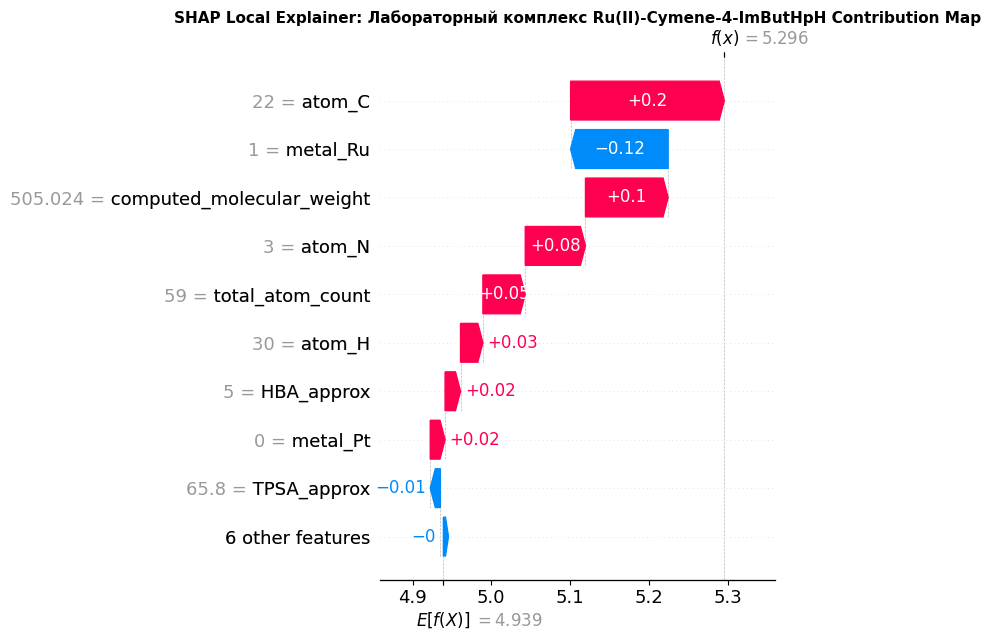


>>> Inference Metrics for [Лабораторный комплекс Rh(III)-Cymene-4-ImButHpH]:
    Formula mapped : Metal=Rh, C=22, N=3, O=2, H=30
    Calculated MW  : 403.95 g/mol
    Predicted pIC50: 5.3085


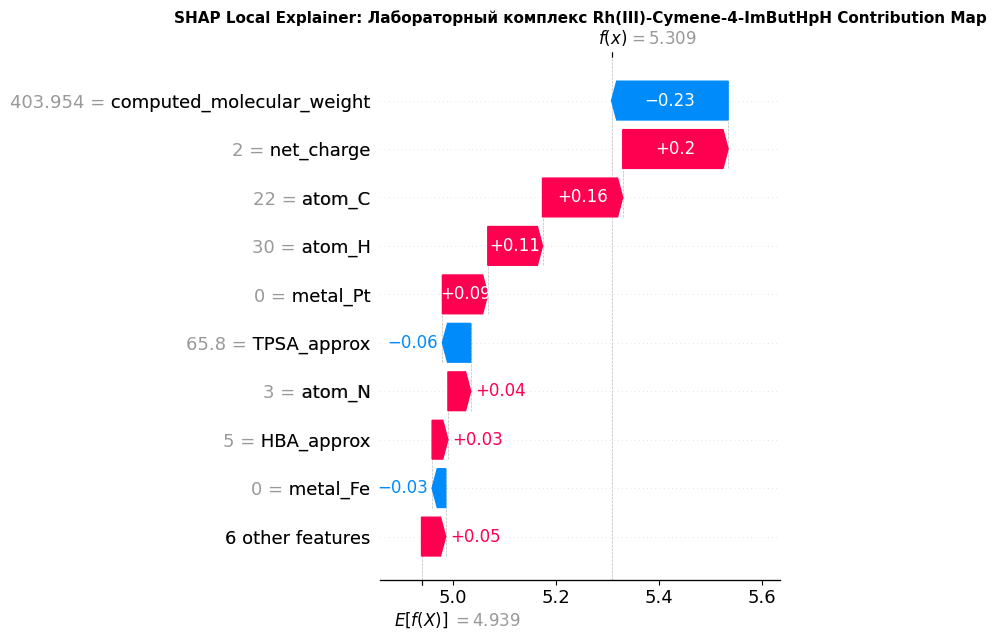


  Результаты расчета: Ru_pIC50 = 5.2958 | Rh_pIC50 = 5.3085


In [18]:
# ==============================================================================
# ПРИМЕНЕНИЕ МОДЕЛИ К ЛАБОРАТОРНЫМ КОМПЛЕКСАМ (Ru / Rh 4-ImButHpH)
# ==============================================================================
print("  Запуск инференса для экспериментальных лабораторных комплексов...")

# Объединенная формула внутренней сферы: Лиганд (C12H16N3O2) + p-cymene (C10H14) + Cl
# Итого: C22 H30 N3 O2 Cl
experimental_ligand_core = "C22H30N3O2Cl"

# 1. Расчет и SHAP-профилирование для Рутениевого комплекса
ru_pred = predict_phase3_organometallic_activity(
    name="Лабораторный комплекс Ru(II)-Cymene-4-ImButHpH",
    metal="Ru",
    net_charge=1.0,  # Ru(II) (+2) - Cl(-1) = +1
    ligand_formula=experimental_ligand_core,
    plot_distribution=False  # Отключаем одиночный график, сделаем совмещенный ниже
)

# 2. Расчет и SHAP-профилирование для Родиевого комплекса
rh_pred = predict_phase3_organometallic_activity(
    name="Лабораторный комплекс Rh(III)-Cymene-4-ImButHpH",
    metal="Rh",      # Автоматически уйдет в базовый уровень (все флаги металлов = 0)
    net_charge=2.0,  # Rh(III) (+3) - Cl(-1) = +2
    ligand_formula=experimental_ligand_core,
    plot_distribution=False
)

print("\n=======================================================")
print(f"  Результаты расчета: Ru_pIC50 = {ru_pred:.4f} | Rh_pIC50 = {rh_pred:.4f}")
print("=======================================================")

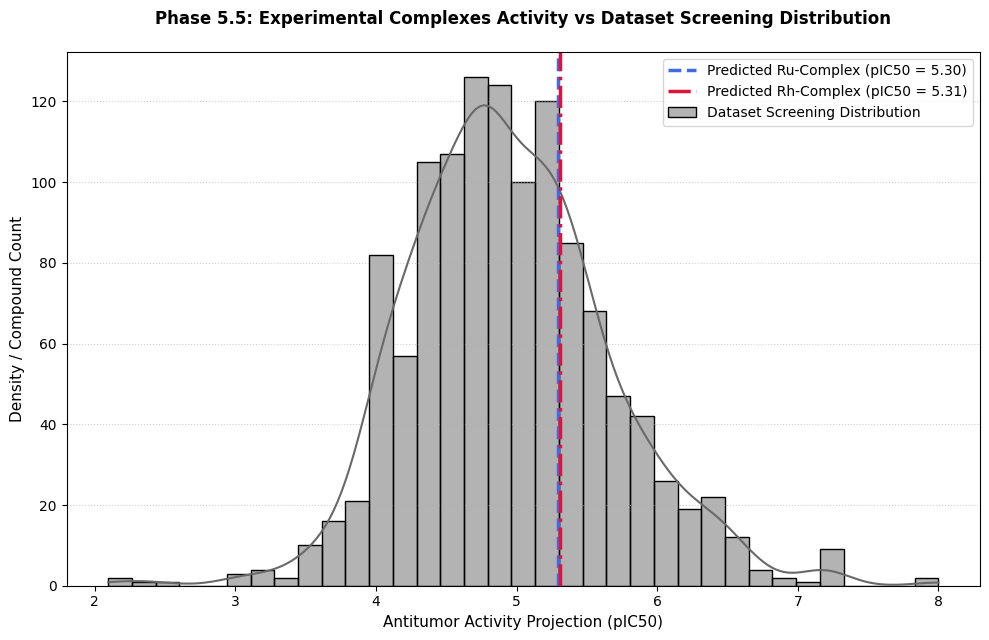

In [19]:
# ==============================================================================
# PHASE 5.5 - DUAL TARGET HISTOGRAM DISTRIBUTION MAPPING
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Построение единого совмещенного графика распределения
plt.figure(figsize=(10, 6.5))

# Отрисовка профиля плотности распределения всего датасета
sns.histplot(
    df['pIC50'], 
    kde=True, 
    color='dimgray', 
    alpha=0.5, 
    label='Dataset Screening Distribution'
)

# Нанесение вертикальной линии для Рутениевого комплекса
plt.axvline(
    x=ru_pred, 
    color='royalblue', 
    linestyle='--', 
    linewidth=2.5, 
    label=f'Predicted Ru-Complex (pIC50 = {ru_pred:.2f})'
)

# Нанесение вертикальной линии для Родиевого комплекса
plt.axvline(
    x=rh_pred, 
    color='crimson', 
    linestyle='-.', 
    linewidth=2.5, 
    label=f'Predicted Rh-Complex (pIC50 = {rh_pred:.2f})'
)

# Стилизация осей и заголовков в строгом академическом стиле
plt.title(
    'Phase 5.5: Experimental Complexes Activity vs Dataset Screening Distribution', 
    fontsize=12, 
    fontweight='bold', 
    pad=20
)
plt.xlabel('Antitumor Activity Projection (pIC50)', fontsize=11)
plt.ylabel('Density / Compound Count', fontsize=11)

# Вывод легенды в верхний правый угол
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=False)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()